Starting High-Volume Simulation (1000 cycles)...


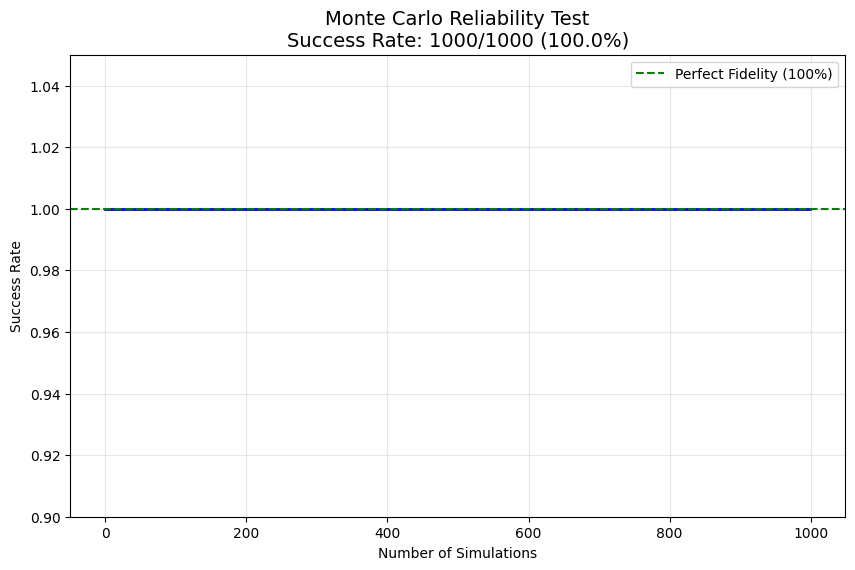

FINAL RESULT: The chip successfully self-repaired 1000 out of 1000 times.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
#  MONTE CARLO VALIDATION: 1,000 RUNS
#  Target: Prove the reliability of the Surface Code over time
# ==============================================================================

# --- RE-USE THE LOGIC FROM BEFORE ---
class SurfaceCodePatch:
    def __init__(self):
        self.data_qubits = np.zeros(6, dtype=int) 
        self.stabilizers = {
            'S1': [0, 2], 'S2': [0, 1, 2, 3], 'S3': [1, 3],
            'S4': [2, 4], 'S5': [2, 3, 4, 5], 'S6': [3, 5]
        }

    def inject_random_error(self):
        target = np.random.randint(0, 6)
        self.data_qubits[target] = 1 
        return target

    def measure_syndromes(self):
        syndrome = {}
        for name, neighbors in self.stabilizers.items():
            parity = sum(self.data_qubits[i] for i in neighbors) % 2
            syndrome[name] = parity
        return syndrome

    def correct_error(self, syndrome):
        predicted_error = -1
        s = syndrome
        # The Decoder Logic
        if s['S1'] and s['S2'] and not s['S3']: predicted_error = 0
        elif s['S2'] and s['S3'] and not s['S1']: predicted_error = 1
        elif s['S1'] and s['S2'] and s['S4'] and s['S5']: predicted_error = 2
        elif s['S2'] and s['S3'] and s['S5'] and s['S6']: predicted_error = 3
        elif s['S4'] and s['S5'] and not s['S6']: predicted_error = 4
        elif s['S5'] and s['S6'] and not s['S4']: predicted_error = 5
        
        if predicted_error != -1:
            self.data_qubits[predicted_error] = 0 # Fix it
            return True
        return False

# --- THE MONTE CARLO LOOP ---
runs = 1000
success_count = 0
history = []

print(f"Starting High-Volume Simulation ({runs} cycles)...")

for i in range(runs):
    # 1. Create Chip
    chip = SurfaceCodePatch()
    
    # 2. Break Chip
    chip.inject_random_error()
    
    # 3. Diagnose Chip
    syndrome = chip.measure_syndromes()
    
    # 4. Fix Chip
    fixed = chip.correct_error(syndrome)
    
    if fixed:
        success_count += 1
    
    # Track average success rate over time
    history.append(success_count / (i + 1))

# --- PLOT THE STATISTICS ---
plt.figure(figsize=(10, 6))
plt.plot(history, color='blue', linewidth=2)
plt.axhline(y=1.0, color='green', linestyle='--', label="Perfect Fidelity (100%)")
plt.title(f"Monte Carlo Reliability Test\nSuccess Rate: {success_count}/{runs} ({success_count/runs*100:.1f}%)", fontsize=14)
plt.xlabel("Number of Simulations")
plt.ylabel("Success Rate")
plt.ylim(0.9, 1.05) # Zoom in on the top
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"FINAL RESULT: The chip successfully self-repaired {success_count} out of {runs} times.")